* Ridge Regression is a variation of linear regression specifically designed to address multicollinearity
* Multicollinearity exists when there are two or more predictors in a regression model that are moderately or highly correlated with one another
* Ridge introduces a penalizer term (L2 penalty) to stablizes the model and prevent overfitting
* Ridge adds shrinkage penalty

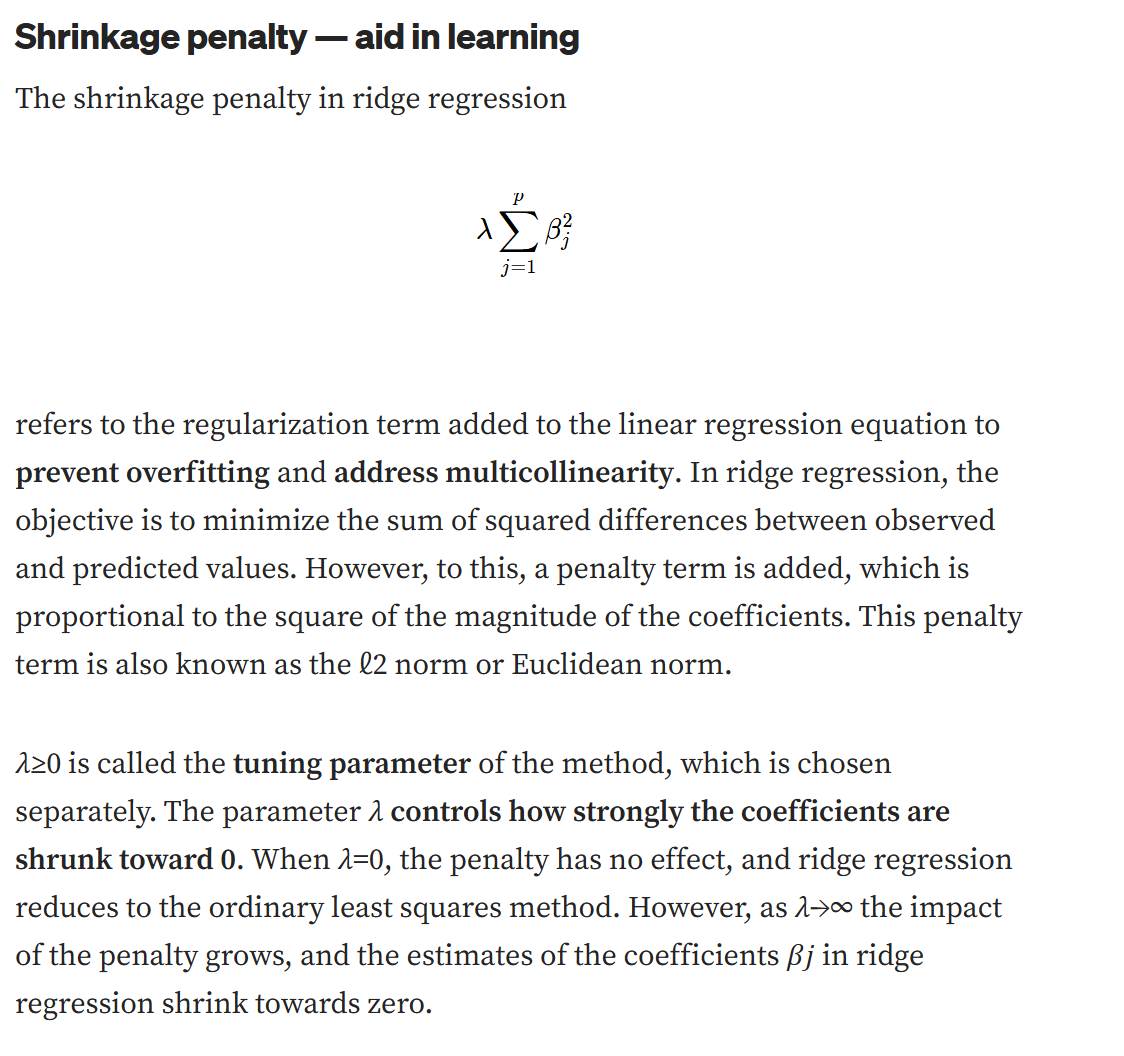

Feature standardization is a preprocessing step in machine learning where the input features are transformed to have a mean of 0 and a standard deviation of 1. This is typically achieved by subtracting the mean of each feature from its values and then dividing by the standard deviation.

If the population mean and population standard deviation are known, a raw variable 𝑥 is converted into a standard score by


Z = X - Mean / Std dev

Let’s try to understand this with an example:
If one of the variables is the price of an apartment (in hundreds of thousands) and the other is the number of rooms in that apartment (in units), it’s difficult to compare both quantities. After standardization, their variables have similar values (though somewhat abstract), but their distribution won’t change.



In [1]:
# Sample problem

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Toy dataset
data = {
    'YearsExperience': [1, 3, 5, 7, 9, 2, 4, 6, 8, 10],
    'Age':             [22, 25, 28, 32, 35, 23, 27, 30, 34, 38],
    'Salary':          [40000, 55000, 70000, 85000, 100000,
                        45000, 62000, 78000, 92000, 110000]
}

df_toy = pd.DataFrame(data)

X = df_toy[['YearsExperience', 'Age']]
y = df_toy['Salary']

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


In [3]:
scaler = pipeline.named_steps['scaler']
ridge  = pipeline.named_steps['ridge']

print("=== SCALED COEFFICIENTS (who matters most) ===")
for feature, coef in zip(X.columns, ridge.coef_):
    print(f"{feature}: {coef:,.2f}")

print(f"Intercept (scaled): {ridge.intercept_:,.2f}")

print("\n=== ORIGINAL SCALE COEFFICIENTS (actual equation) ===")
original_coefs = ridge.coef_ / scaler.scale_
original_intercept = ridge.intercept_ - np.sum(ridge.coef_ * scaler.mean_ / scaler.scale_)

for feature, coef in zip(X.columns, original_coefs):
    print(f"{feature}: {coef:,.2f}")

print(f"Intercept: {original_intercept:,.2f}")


=== SCALED COEFFICIENTS (who matters most) ===
YearsExperience: 10,730.55
Age: 10,457.80
Intercept (scaled): 73,700.00

=== ORIGINAL SCALE COEFFICIENTS (actual equation) ===
YearsExperience: 3,735.90
Age: 2,065.29
Intercept: -7,567.01


## Ridge regression adds a penalty term:
Loss = RSS + α × (coef1² + coef2² + coef3²...)
It penalizes large coefficients. Now think about your features without scaling:

Revenue coefficient might be 0.005 (because Revenue is in millions)
Is_Public coefficient might be 800,000 (because it's a 0/1 flag)

Ridge sees Is_Public's coefficient as enormous and penalizes it heavily — even though it might be equally or less important than Revenue. You're penalizing based on units, not importance.

After standardization, all coefficients are on the same scale so Ridge penalizes them fairly.